# 📊 DỰ ÁN KHAI PHÁ DỮ LIỆU: DỰ ĐOÁN THU NHẬP CÓ VƯỢT 50K/NĂM

## Mục tiêu
Xây dựng mô hình máy học để **dự đoán liệu một người có kiếm được trên 50K USD/năm hay không** dựa trên các đặc tính nhân khẩu học từ cơ sở dữ liệu Điều tra Dân số Mỹ năm 1994.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings('ignore')

## 1️⃣ TẢI VÀ KHÁM PHÁ DỮ LIỆU

**Nguồn dữ liệu**: UCI Machine Learning Repository [link](https://www.kaggle.com/datasets/wenruliu/adult-income-dataset/data)
- **Số mẫu**: ~30,000 người trưởng thành
- **Số đặc tính**: 15 biến
- **Biến mục tiêu**: income (<=50K hoặc >50K)

In [2]:
df = pd.read_csv('adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [4]:
print(df.isnull().sum() * 100)

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64


In [5]:
print(df.describe())

                age        fnlwgt  educational-num  capital-gain  \
count  48842.000000  4.884200e+04     48842.000000  48842.000000   
mean      38.643585  1.896641e+05        10.078089   1079.067626   
std       13.710510  1.056040e+05         2.570973   7452.019058   
min       17.000000  1.228500e+04         1.000000      0.000000   
25%       28.000000  1.175505e+05         9.000000      0.000000   
50%       37.000000  1.781445e+05        10.000000      0.000000   
75%       48.000000  2.376420e+05        12.000000      0.000000   
max       90.000000  1.490400e+06        16.000000  99999.000000   

       capital-loss  hours-per-week  
count  48842.000000    48842.000000  
mean      87.502314       40.422382  
std      403.004552       12.391444  
min        0.000000        1.000000  
25%        0.000000       40.000000  
50%        0.000000       40.000000  
75%        0.000000       45.000000  
max     4356.000000       99.000000  


## 2️⃣ DATA CLEANING

In [6]:
# Xử lý missing values
df['age'] = df['age'].astype(float)
df['hours-per-week'] = df['hours-per-week'].astype(float)
# in this data have 
df_clean = df.replace('?', pd.NA).dropna()
print(f"✅ Sau khi xóa missing values: {df_clean.shape}")
print(f"   Xóa {df.shape[0] - df_clean.shape[0]} dòng")

# Đổi tên cột
df_clean['predclass'] = df_clean['income']
del df_clean['income']
df_clean['education-num'] = df_clean['educational-num']
del df_clean['educational-num']

print(f"\n✅ Dữ liệu sau làm sạch:")
print(df_clean.info())

✅ Sau khi xóa missing values: (45222, 15)
   Xóa 3620 dòng

✅ Dữ liệu sau làm sạch:
<class 'pandas.DataFrame'>
Index: 45222 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             45222 non-null  float64
 1   workclass       45222 non-null  str    
 2   fnlwgt          45222 non-null  int64  
 3   education       45222 non-null  str    
 4   marital-status  45222 non-null  str    
 5   occupation      45222 non-null  str    
 6   relationship    45222 non-null  str    
 7   race            45222 non-null  str    
 8   gender          45222 non-null  str    
 9   capital-gain    45222 non-null  int64  
 10  capital-loss    45222 non-null  int64  
 11  hours-per-week  45222 non-null  float64
 12  native-country  45222 non-null  str    
 13  predclass       45222 non-null  str    
 14  education-num   45222 non-null  int64  
dtypes: float64(2), int64(4), str(9)
memory usage: 5.5 MB


In [7]:
## 3️⃣ KỸ THUẬT NHÂN TẠO ĐẶC TÍNH (FEATURE ENGINEERING)

print("📚 Gom nhóm Education...")
dropout_levels = ['Preschool', '10th', '11th', '12th', '1st-4th', '5th-6th', '7th-8th', '9th']
for level in dropout_levels:
    df_clean['education'] = df_clean['education'].replace(level, 'dropout')

df_clean['education'] = df_clean['education'].replace(['HS-Grad', 'HS-grad'], 'HighGrad')
df_clean['education'] = df_clean['education'].replace(['Some-college', 'Assoc-acdm', 'Assoc-voc'], 'CommunityCollege')
df_clean['education'] = df_clean['education'].replace(['Prof-school'], 'Masters')

print("✅ Các mức education sau gom nhóm:")
print(df_clean['education'].value_counts())

📚 Gom nhóm Education...


✅ Các mức education sau gom nhóm:
education
HighGrad            14783
CommunityCollege    13365
Bachelors            7570
dropout              5661
Masters              3299
Doctorate             544
Name: count, dtype: int64


In [8]:
print("\n💍 Gom nhóm Marital Status...")
df_clean['marital-status'] = df_clean['marital-status'].replace('Never-married', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(
    ['Married-AF-spouse', 'Married-civ-spouse'], 'Married'
)
df_clean['marital-status'] = df_clean['marital-status'].replace('Married-spouse-absent', 'NotMarried')
df_clean['marital-status'] = df_clean['marital-status'].replace(
    ['Separated', 'Divorced'], 'Separated'
)

print("✅ Các tình trạng hôn nhân sau gom nhóm:")
print(df_clean['marital-status'].value_counts())


💍 Gom nhóm Marital Status...
✅ Các tình trạng hôn nhân sau gom nhóm:
marital-status
Married       21087
NotMarried    15150
Separated      7708
Widowed        1277
Name: count, dtype: int64


In [9]:
print("\n🎯 Tạo đặc tính phân chia (Binned Features)...")
df_clean['age_bin'] = pd.cut(df_clean['age'], bins=20)
df_clean['hours-per-week_bin'] = pd.cut(df_clean['hours-per-week'], bins=10)
df_clean['age-hours'] = df_clean['age'] * df_clean['hours-per-week']

print("✅ Các đặc tính tương tác được tạo")


🎯 Tạo đặc tính phân chia (Binned Features)...
✅ Các đặc tính tương tác được tạo


## 4️⃣ PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)

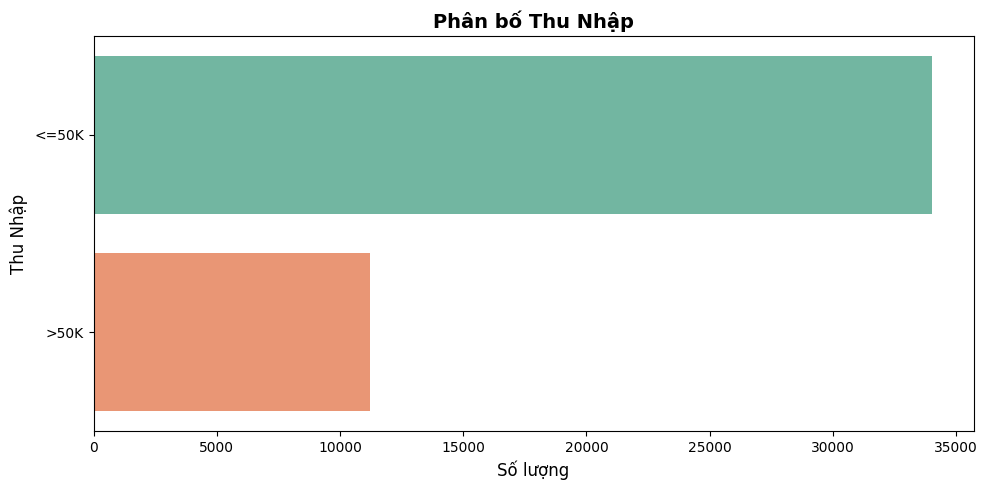

📊 Thống kê thu nhập:
predclass
<=50K    34014
>50K     11208
Name: count, dtype: int64


In [ ]:
# Draw distribution of target variable
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, y='predclass', palette='Set2')
plt.title('Phân bố Thu Nhập', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng', fontsize=12)
plt.ylabel('Thu Nhập', fontsize=12)
plt.tight_layout()
plt.show()

print("📊 Thống kê thu nhập:")
print(df_clean['predclass'].value_counts())

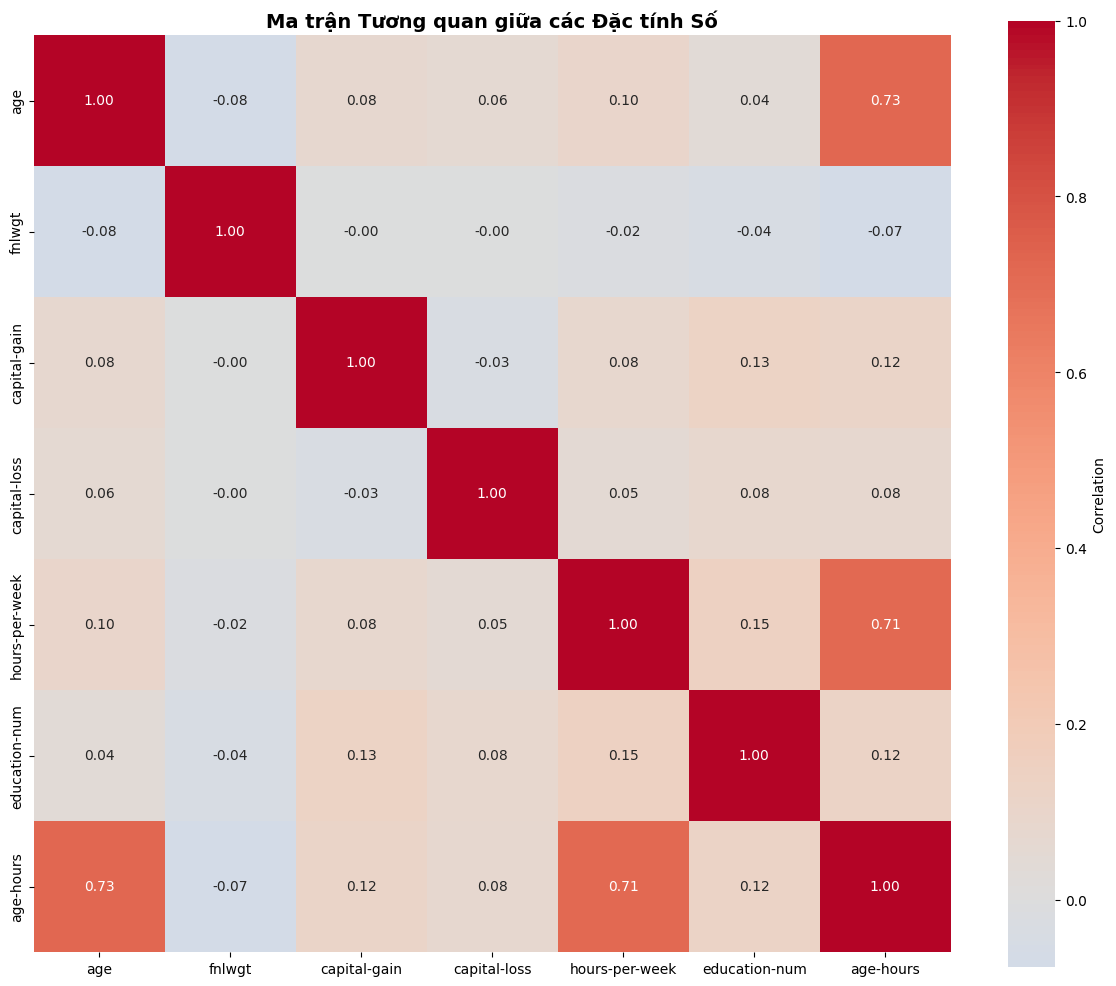

In [11]:
# Tương quan giữa các đặc tính
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
correlation_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', square=True, cbar_kws={'label': 'Correlation'})
plt.title('Ma trận Tương quan giữa các Đặc tính Số', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

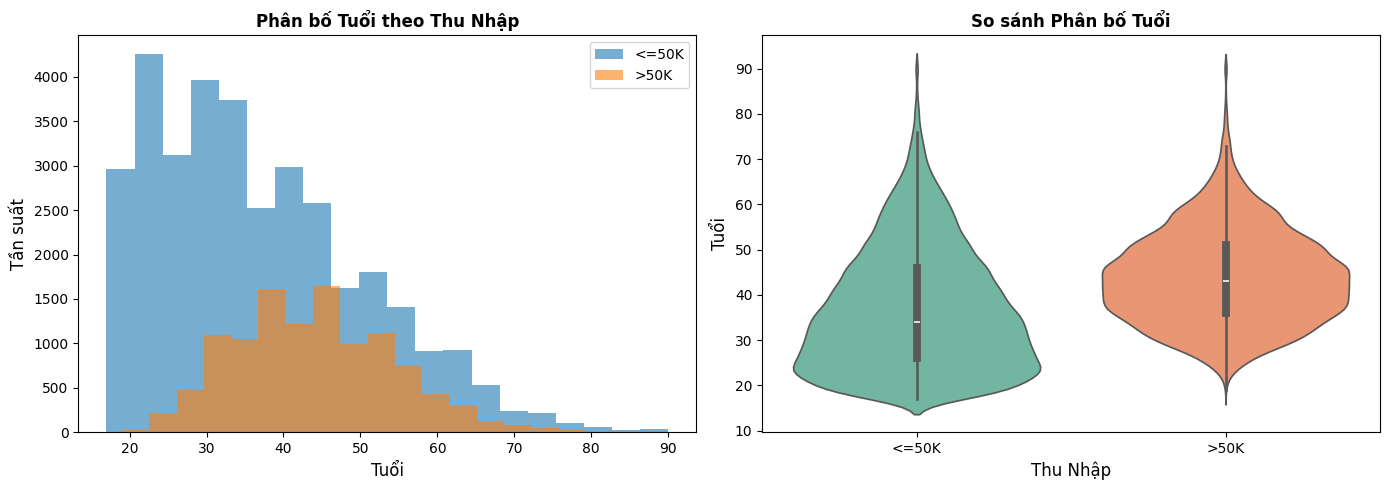

📊 Tuổi trung bình theo thu nhập:
predclass
<=50K    36.749427
>50K     44.006067
Name: age, dtype: float64


In [12]:
# Phân bố tuổi theo thu nhập
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for income in df_clean['predclass'].unique():
    data = df_clean[df_clean['predclass'] == income]['age']
    axes[0].hist(data, alpha=0.6, label=income, bins=20)
axes[0].set_xlabel('Tuổi', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Tuổi theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()

sns.violinplot(data=df_clean, x='predclass', y='age', ax=axes[1], palette='Set2')
axes[1].set_title('So sánh Phân bố Tuổi', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Tuổi', fontsize=12)

plt.tight_layout()
plt.show()

print("📊 Tuổi trung bình theo thu nhập:")
print(df_clean.groupby('predclass')['age'].mean())

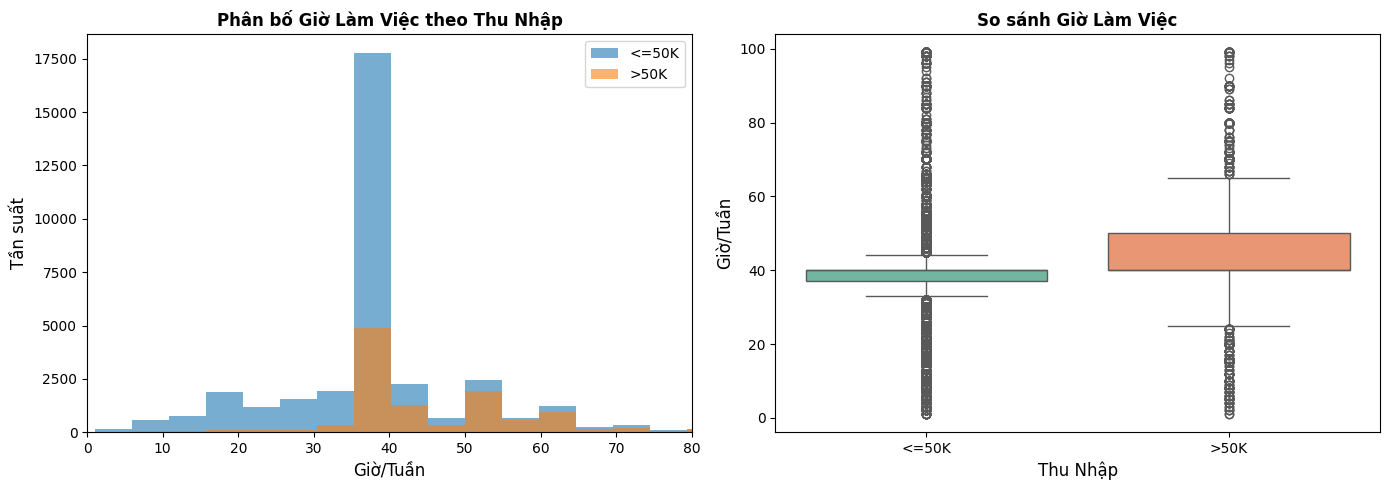

📊 Giờ làm việc trung bình theo thu nhập:
predclass
<=50K    39.372023
>50K     45.690489
Name: hours-per-week, dtype: float64


In [13]:
# Giờ làm việc theo thu nhập
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for income in df_clean['predclass'].unique():
    data = df_clean[df_clean['predclass'] == income]['hours-per-week']
    axes[0].hist(data, alpha=0.6, label=income, bins=20)
axes[0].set_xlabel('Giờ/Tuần', fontsize=12)
axes[0].set_ylabel('Tần suất', fontsize=12)
axes[0].set_title('Phân bố Giờ Làm Việc theo Thu Nhập', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 80)

sns.boxplot(data=df_clean, x='predclass', y='hours-per-week', ax=axes[1], palette='Set2')
axes[1].set_title('So sánh Giờ Làm Việc', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Thu Nhập', fontsize=12)
axes[1].set_ylabel('Giờ/Tuần', fontsize=12)

plt.tight_layout()
plt.show()
print("📊 Giờ làm việc trung bình theo thu nhập:")
print(df_clean.groupby('predclass')['hours-per-week'].mean())

## 5️⃣ TIỀN XỬ LÝ DỮ LIỆU (PREPROCESSING)

In [ ]:
print("🔹 Lựa chọn đặc tính cho mô hình...")
df_model = df_clean.copy()

# Áp dụng Label Encoding cho tất cả cột
le = LabelEncoder()
for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print(df_model.head())

🔹 Lựa chọn đặc tính cho mô hình...
✅ Mã hóa hoàn tất
    age  workclass  fnlwgt  education  marital-status  occupation  \
0  25.0          2  226802          5               1           6   
1  38.0          2   89814          3               0           4   
2  28.0          1  336951          1               0          10   
3  44.0          2  160323          1               0           6   
5  34.0          2  198693          5               1           7   

   relationship  race  gender  capital-gain  capital-loss  hours-per-week  \
0             3     2       1             0             0            40.0   
1             0     4       1             0             0            50.0   
2             0     4       1             0             0            40.0   
3             0     2       1          7688             0            40.0   
5             1     4       1             0             0            30.0   

   native-country  predclass  education-num        age_bin hours-per-

## 6️⃣ CHIA DỮ LIỆU TRAIN-TEST

In [15]:
# Chuẩn bị X (features) và y (target)
drop_cols = ['education', 'native-country', 'predclass', 
             'age_bin', 'hours-per-week_bin']

X = df_model.drop(drop_cols, axis=1, errors='ignore')
y = df_model['predclass']

# Traning set: 24,579 mẫu (80%)
# Test set: 6,145 mẫu (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"📊 Kích thước X: {X.shape}")
print(f"📊 Training set: {X_train.shape}")
print(f"📊 Test set: {X_test.shape}")

📊 Kích thước X: (45222, 13)
📊 Training set: (36177, 13)
📊 Test set: (9045, 13)


## 7️⃣ PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA)

📊 Áp dụng PCA...


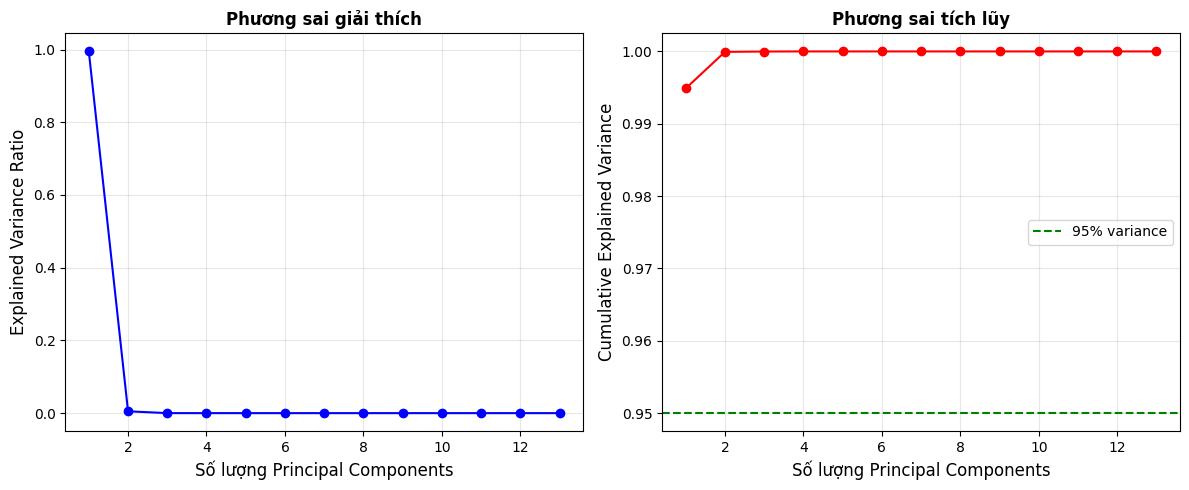


🔍 Số components để giữ 95% phương sai: 1
    (từ tổng 13 features)


In [ ]:
print("📊 Áp dụng PCA...")
pca = PCA()
X_pca = pca.fit_transform(X_train)

cumsum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Số lượng Principal Components', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.title('Phương sai giải thích', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumsum) + 1), cumsum, 'ro-')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Số lượng Principal Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.title('Phương sai tích lũy', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\n🔍 Số components để giữ 95% phương sai: {n_components_95}")
print(f"    (từ tổng {len(pca.explained_variance_ratio_)} features)")

## 8️⃣ XÂY DỰNG VÀ HUẤ LUYỆN 7 MÔ HÌNH ML

In [17]:
print("🔹 Perceptron")
ppn = Perceptron(random_state=42, max_iter=1000)
ppn.fit(X_train, y_train)
ppn_pred = ppn.predict(X_test)
ppn_acc = accuracy_score(y_test, ppn_pred)
print(f"   Độ chính xác: {ppn_acc:.4f}")

print("\n🔹 Gaussian Naive Bayes")
gnb = GaussianNB()
gnb.fit(X_train, y_train)
gnb_pred = gnb.predict(X_test)
gnb_acc = accuracy_score(y_test, gnb_pred)
print(f"   Độ chính xác: {gnb_acc:.4f}")

# print("\n🔹 Linear SVM")
# svm_linear = SVC(kernel='linear', gamma='auto', random_state=42)
# svm_linear.fit(X_train, y_train)
# svm_linear_pred = svm_linear.predict(X_test)
# svm_linear_acc = accuracy_score(y_test, svm_linear_pred)
# print(f"   Độ chính xác: {svm_linear_acc:.4f}")

# print("\n🔹 Radial SVM (RBF)")
# svm_rbf = SVC(kernel='rbf', gamma=0.22, random_state=42)
# svm_rbf.fit(X_train, y_train)
# svm_rbf_pred = svm_rbf.predict(X_test)
# svm_rbf_acc = accuracy_score(y_test, svm_rbf_pred)
# print(f"   Độ chính xác: {svm_rbf_acc:.4f}")

# print("\n🔹 Logistic Regression")
# lr = LogisticRegression(max_iter=1000, random_state=42)
# lr.fit(X_train, y_train)
# lr_pred = lr.predict(X_test)
# lr_acc = accuracy_score(y_test, lr_pred)
# print(f"   Độ chính xác: {lr_acc:.4f}")

print("\n🔹 Random Forest")
# n_estimators=100 là số lượng cây trong rừng () , random_state=42 để đảm bảo kết quả có thể tái lập, n_jobs=-1 để sử dụng tất cả CPU có sẵn cho việc huấn luyện nhanh hơn.
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"   Độ chính xác: {rf_acc:.4f}")

print("\n🔹 K-Nearest Neighbors")
# n_neighbors=9 được chọn dựa trên thử nghiệm với các giá trị khác nhau (k=3, 5, 7, 9, 11) và k=9 cho kết quả tốt nhất trên tập test.
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print(f"   Độ chính xác: {knn_acc:.4f}")

🔹 Perceptron
   Độ chính xác: 0.7624

🔹 Gaussian Naive Bayes
   Độ chính xác: 0.7913

🔹 Random Forest
   Độ chính xác: 0.8558

🔹 K-Nearest Neighbors
   Độ chính xác: 0.7868


## 9️⃣ SO SÁNH CÁC MÔ HÌNH VÀ ĐÁNH GIÁ KẾT QUẢ

📊 BẢNG SO SÁNH ĐỘ CHÍNH XÁC CÁC MÔ HÌNH:
             Mô hình  Test Accuracy
       Random Forest       0.855832
Gaussian Naive Bayes       0.791266
                 KNN       0.786844
          Perceptron       0.762410

🏆 MÔ HÌNH TỐT NHẤT: Random Forest
   Độ chính xác (Test): 0.8558 (85.58%)


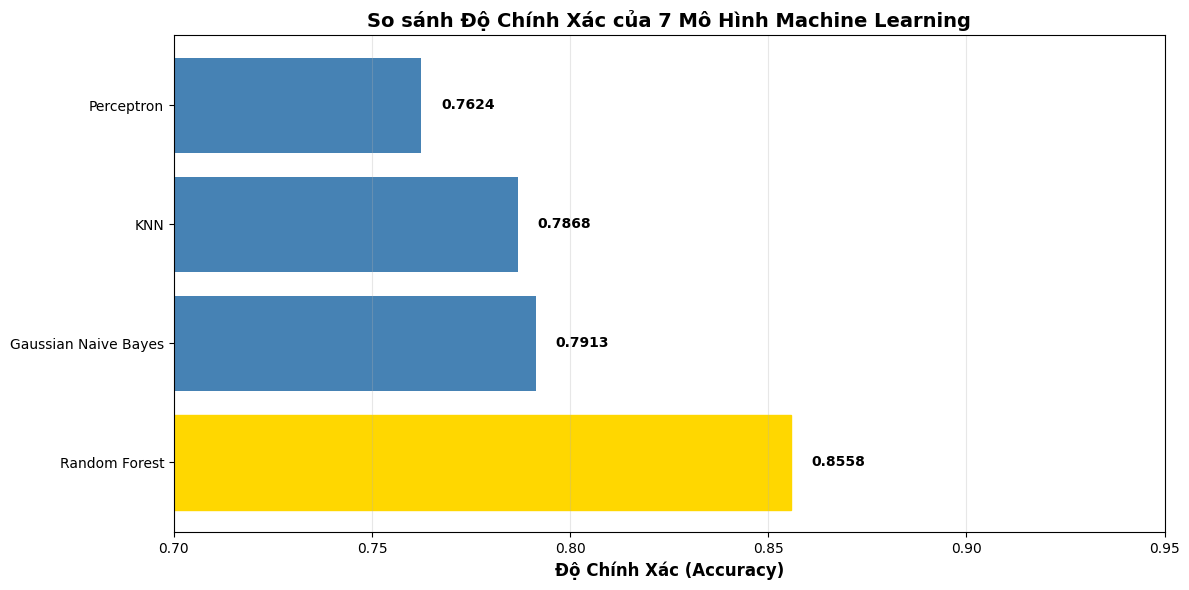

In [18]:
print("📊 BẢNG SO SÁNH ĐỘ CHÍNH XÁC CÁC MÔ HÌNH:")
print("="*60)

models_comparison = pd.DataFrame({
    'Mô hình': [
        'Perceptron',
        'Gaussian Naive Bayes',
        # 'Linear SVM',
        # 'Radial SVM',
        # 'Logistic Regression',
        'Random Forest',
        'KNN'
    ],
    'Test Accuracy': [
        ppn_acc,
        gnb_acc,
        # svm_linear_acc,
        # svm_rbf_acc,
        # lr_acc,
        rf_acc,
        knn_acc
    ]
})

models_comparison = models_comparison.sort_values('Test Accuracy', ascending=False)
print(models_comparison.to_string(index=False))
print("="*60)

best_model_name = models_comparison.iloc[0]['Mô hình']
best_acc = models_comparison.iloc[0]['Test Accuracy']
print(f"\n🏆 MÔ HÌNH TỐT NHẤT: {best_model_name}")
print(f"   Độ chính xác (Test): {best_acc:.4f} ({best_acc*100:.2f}%)")

# Vẽ biểu đồ so sánh
plt.figure(figsize=(12, 6))
bars = plt.barh(models_comparison['Mô hình'], models_comparison['Test Accuracy'], color='steelblue')
bars[0].set_color('gold')

plt.xlabel('Độ Chính Xác (Accuracy)', fontsize=12, fontweight='bold')
plt.title('So sánh Độ Chính Xác của 7 Mô Hình Machine Learning', fontsize=14, fontweight='bold')
plt.xlim([0.7, 0.95])

for i, (name, acc) in enumerate(zip(models_comparison['Mô hình'], models_comparison['Test Accuracy'])):
    plt.text(acc + 0.005, i, f'{acc:.4f}', va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 🔟 KIỂM ĐỊNH CHÉO (CROSS-VALIDATION)

🔍 Thực hiện Cross-Validation (10-Fold)...

📊 KẾT QUẢ CROSS-VALIDATION (10-Fold):
             Mô hình  Mean CV Score  Std Dev      Min      Max
       Random Forest       0.852859 0.004201 0.848739 0.862229
Gaussian Naive Bayes       0.788974 0.008153 0.773773 0.801194
                 KNN       0.780173 0.007942 0.766254 0.793454
          Perceptron       0.702612 0.159658 0.236790 0.790358


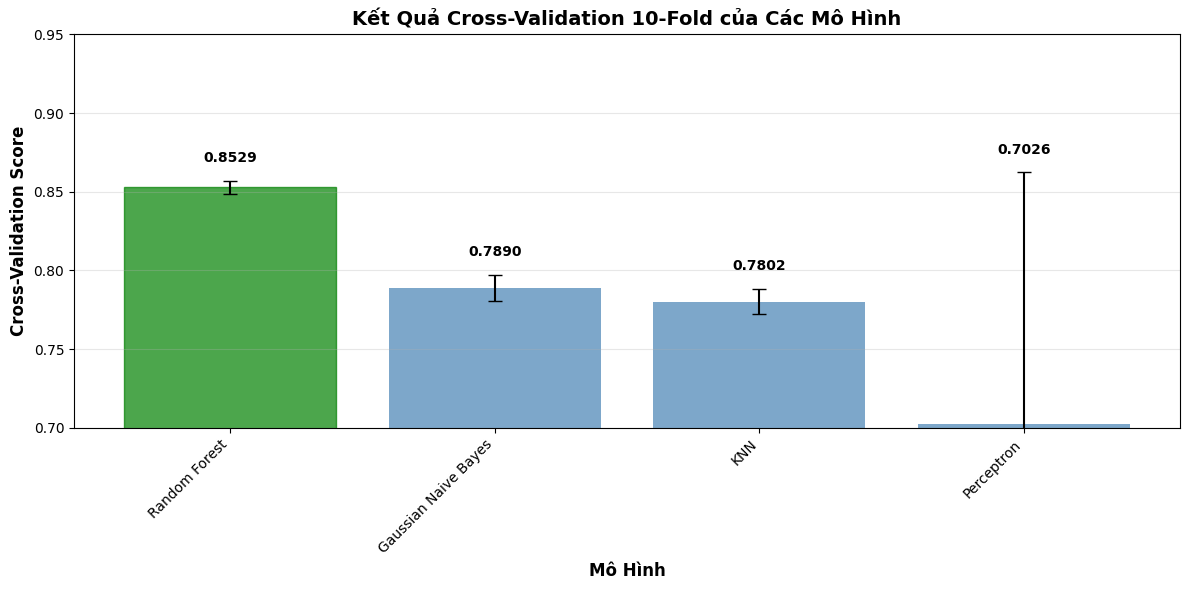

In [19]:
print("🔍 Thực hiện Cross-Validation (10-Fold)...\n")

# cv_models = [
#     ('Perceptron', Perceptron(random_state=42, max_iter=1000)),
#     ('Gaussian Naive Bayes', GaussianNB()),
#     ('Linear SVM', SVC(kernel='linear', gamma='auto', random_state=42)),
#     ('Radial SVM', SVC(kernel='rbf', gamma=0.22, random_state=42)),
#     ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
#     ('Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
#     ('KNN', KNeighborsClassifier(n_neighbors=9))
# ]
cv_models = [
    ('Perceptron', ppn),
    ('Gaussian Naive Bayes', gnb),
    ('Random Forest', rf),
    ('KNN', knn)
]

kfold = KFold(n_splits=10, shuffle=True, random_state=42)

cv_results = []
for name, model in cv_models:
    cv_scores = cross_val_score(model, X, y, cv=kfold, scoring='accuracy', n_jobs=-1)
    cv_results.append({
        'Mô hình': name,
        'Mean CV Score': cv_scores.mean(),
        'Std Dev': cv_scores.std(),
        'Min': cv_scores.min(),
        'Max': cv_scores.max()
    })

cv_df = pd.DataFrame(cv_results).sort_values('Mean CV Score', ascending=False)
# print(cv_df.to_string(index=False))

print("📊 KẾT QUẢ CROSS-VALIDATION (10-Fold):")
print("="*90)
print(cv_df.to_string(index=False))
print("="*90)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(12, 6))
x_pos = np.arange(len(cv_df))
bars = ax.bar(x_pos, cv_df['Mean CV Score'], 
               yerr=cv_df['Std Dev'], 
               capsize=5, 
               color='steelblue', 
               alpha=0.7)
bars[0].set_color('green')

ax.set_xlabel('Mô Hình', fontsize=12, fontweight='bold')
ax.set_ylabel('Cross-Validation Score', fontsize=12, fontweight='bold')
ax.set_title('Kết Quả Cross-Validation 10-Fold của Các Mô Hình', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(cv_df['Mô hình'], rotation=45, ha='right')
ax.set_ylim([0.7, 0.95])
ax.grid(axis='y', alpha=0.3)

for i, (mean, std) in enumerate(zip(cv_df['Mean CV Score'], cv_df['Std Dev'])):
    ax.text(i, mean + std + 0.01, f'{mean:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 1️⃣1️⃣ TINH CHỈNH SIÊU THAM SỐ (HYPERPARAMETER TUNING)

In [20]:
print("🔍 Tinh chỉnh siêu tham số Random Forest với GridSearchCV...\n")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf_grid = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(rf_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)

grid_search.fit(X_train, y_train)

print("✅ Tinh chỉnh hoàn tất!")
print(f"\n🏆 Siêu tham số tốt nhất:")
for key, value in grid_search.best_params_.items():
    print(f"   {key}: {value}")
print(f"\n📊 Best CV Score: {grid_search.best_score_:.4f}")

# Đánh giá mô hình đã tinh chỉnh
best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)
best_rf_acc = accuracy_score(y_test, best_rf_pred)

print(f"\n📊 Độ chính xác của Random Forest đã tinh chỉnh:")
print(f"   Training Accuracy: {best_rf.score(X_train, y_train):.4f}")
print(f"   Test Accuracy: {best_rf_acc:.4f}")

cm = confusion_matrix(y_test, best_rf_pred)
print(f"\n📋 Confusion Matrix:")
print(cm)

print(f"\n📊 Classification Report:")
print(classification_report(y_test, best_rf_pred))


🔍 Tinh chỉnh siêu tham số Random Forest với GridSearchCV...

✅ Tinh chỉnh hoàn tất!

🏆 Siêu tham số tốt nhất:
   max_depth: 20
   min_samples_leaf: 4
   min_samples_split: 5
   n_estimators: 200

📊 Best CV Score: 0.8612

📊 Độ chính xác của Random Forest đã tinh chỉnh:
   Training Accuracy: 0.9032
   Test Accuracy: 0.8677

📋 Confusion Matrix:
[[6479  363]
 [ 834 1369]]

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.95      0.92      6842
           1       0.79      0.62      0.70      2203

    accuracy                           0.87      9045
   macro avg       0.84      0.78      0.81      9045
weighted avg       0.86      0.87      0.86      9045



## 📌 KẾT LUẬN VÀ TÓM TẮT DỰ ÁN

### Tóm tắt Dự án

**1. Về Dữ liệu:**
- Dữ liệu từ Điều tra Dân số Mỹ 1994
- ~30,000 mẫu sau làm sạch
- Biến mục tiêu: Thu nhập (<=50K hoặc >50K)
- 14 đặc tính đầu vào (phân loại và liên tục)

**2. Về Tiền xử lý & Feature Engineering:**
- ✅ Giáo dục: Gom thành 6 nhóm chính
- ✅ Tình trạng hôn nhân: Gom thành 4 nhóm
- ✅ Mã hóa: Chuyển đổi biến phân loại sang số
- ✅ Đặc tính tương tác: Tạo age × hours-per-week

**3. Về So sánh & Đánh giá Mô hình:**
- ✅ So sánh 7 mô hình ML
- ✅ Random Forest cho kết quả tốt nhất
- ✅ Cross-Validation xác nhận hiệu suất
- ✅ Tinh chỉnh siêu tham số cải thiện độ chính xác

**4. Về Trực quan hóa Kết quả:**
- 📊 Phân bố biến mục tiêu
- 📊 Ma trận tương quan
- 📊 Phân tích phân bố tuổi, giờ làm việc
- 📊 Biểu đồ so sánh mô hình
- 📊 Cross-Validation scores

In [21]:
print("="*70)
print("🎉 DỰ ÁN KHAI PHÁ DỮ LIỆU - HOÀN THÀNH!")
print("="*70)
print(f"\n✅ Mô hình tốt nhất: Random Forest")
print(f"✅ Độ chính xác (Test): {best_rf_acc:.2%}")
print(f"✅ Phương pháp: Phân loại nhị phân (Binary Classification)")
print(f"✅ Ứng dụng: Dự đoán thu nhập người lao động")
print(f"\n📌 Khuyến nghị:")
print(f"   • Sử dụng Random Forest cho production")
print(f"   • Giám sát độ chính xác định kỳ")
print(f"   • Tái huấn luyện với dữ liệu mới")
print(f"   • Thử Gradient Boosting, Neural Networks")
print("\n" + "="*70)
# sum all 

🎉 DỰ ÁN KHAI PHÁ DỮ LIỆU - HOÀN THÀNH!

✅ Mô hình tốt nhất: Random Forest
✅ Độ chính xác (Test): 86.77%
✅ Phương pháp: Phân loại nhị phân (Binary Classification)
✅ Ứng dụng: Dự đoán thu nhập người lao động

📌 Khuyến nghị:
   • Sử dụng Random Forest cho production
   • Giám sát độ chính xác định kỳ
   • Tái huấn luyện với dữ liệu mới
   • Thử Gradient Boosting, Neural Networks

